<a href="https://colab.research.google.com/github/serdararici/breast-cancer-knn-svm-classification/blob/main/Breast_Cancer_KNN_vs_SVM_HSD_Bootcamp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Meme Kanseri Teşhisinde Makine Öğrenmesi: KNN vs SVM Karşılaştırması

**Huawei Student Developers – Veri Bilimi ve Makine Öğrenmesi Bootcamp Final Projesi**

---

**Hazırlayan:** Serdar Arıcı
**Tarih:** Ağustos 2026
**Bootcamp:** Türkiye Yapay Zeka Akademisi × Huawei Student Developers — Veri Bilimi ve Makine Öğrenmesi Bootcamp

---

## 📌 Proje Amacı

Bu projede, **Breast Cancer Wisconsin (Diagnostic) Dataset** kullanılarak, hücre çekirdeği ölçümlerinden yola çıkarak bir tümörün **iyi huylu (benign)** mu yoksa **kötü huylu (malignant)** mu olduğunu tahmin eden bir sınıflandırma modeli geliştirilecektir.

İki farklı makine öğrenmesi algoritması — **K-En Yakın Komşu (KNN)** ve **Destek Vektör Makineleri (SVM)** — eğitilecek, hiperparametreleri optimize edilecek ve performansları çeşitli metriklerle karşılaştırılacaktır.

## 📊 Veri Seti Hakkında

- **Kaynak:** [Kaggle - Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)
- **Gözlem sayısı:** 569
- **Özellik sayısı:** 30 sayısal özellik (hücre çekirdeğinin yarıçapı, dokusu, çevresi, alanı, pürüzsüzlüğü vb. ölçümlerin ortalama, standart hata ve "en kötü" değerleri)
- **Hedef değişken:** `diagnosis` — M (Malignant / Kötü Huylu) veya B (Benign / İyi Huylu)

## 🛠️ İzlenecek Yol

1. Veri Yükleme ve Genel Bakış
2. Keşifsel Veri Analizi (EDA)
3. Veri Ön İşleme
4. Model 1: K-En Yakın Komşu (KNN)
5. Model 2: Destek Vektör Makineleri (SVM)
6. Model Karşılaştırması ve Değerlendirme
7. Sonuç ve Çıkarımlar

---

## 🔧 Gerekli Kütüphanelerin Yüklenmesi

Analiz, modelleme ve görselleştirme için kullanacağımız kütüphaneleri içe aktarıyoruz.

In [1]:
# Data manipulation libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing, models, and evaluation metrics
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay
)

# Set plotting style for a clean and professional look
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

# Fix random seed for reproducibility across the whole notebook
RANDOM_STATE = 42

print("All libraries imported successfully.")

All libraries imported successfully.


## 1️⃣ Veri Yükleme ve Genel Bakış

Veri setini Google Drive üzerinden Colab ortamına bağlayarak okuyoruz. Veri seti, Kaggle'daki "Breast Cancer Wisconsin (Diagnostic) Data Set" kaynağından indirilmiştir.

In [6]:
# Mount Google Drive to access the dataset file
from google.colab import drive
drive.mount('/content/drive')

# Define the path to the dataset on Google Drive
DATA_PATH = "/content/drive/MyDrive/MachineLearning-AI-DataScience/TurkiyeYapayZekaAkademisi/finalProject/data.csv"

# Load the dataset into a pandas DataFrame
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Veri setinde **569 gözlem** ve **569 hasta kaydı, 30 sayısal özellik** bulunuyor. `id` sütunu sadece hasta kimlik numarası (modelleme için anlamsız), `Unnamed: 32` sütunu ise tamamen boş görünüyor — bu iki sütunu veri temizliği aşamasında çıkaracağız.

Her özellik, hücre çekirdeğinin bir karakteristiğini (yarıçap, doku, çevre, alan, pürüzsüzlük vb.) üç farklı istatistik üzerinden ifade ediyor: ortalama (`mean`), standart hata (`se`), ve en kötü değer (`worst`).

In [7]:
# General information about the dataset: column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [8]:
# Drop irrelevant columns:
# - 'id' is just a patient identifier, not useful for prediction
# - 'Unnamed: 32' is a completely empty column (artifact of the CSV export)
df = df.drop(columns=["id", "Unnamed: 32"])

print(f"Dataset shape after cleanup: {df.shape}")
df.head()

Dataset shape after cleanup: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
# Check for missing values across all remaining columns
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values in the dataset")

Missing values per column:
0 total missing values in the dataset


✅ Veri setinde **hiç eksik değer bulunmuyor**. Bu, veri ön işleme aşamasını önemli ölçüde kolaylaştırıyor.

In [10]:
# Descriptive statistics for all numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## 2️⃣ Keşifsel Veri Analizi (EDA)

Bu bölümde, hedef değişkenin dağılımını, özellikler arasındaki ilişkileri ve sınıflar arasındaki farkları görselleştirerek veriyi daha iyi anlamaya çalışacağız.

### 2.1. Hedef Değişken Dağılımı

İlk olarak, iyi huylu (Benign) ve kötü huylu (Malignant) vakaların veri setindeki dağılımına bakalım. Bu, sınıf dengesizliği (class imbalance) olup olmadığını anlamamız açısından önemli.

In [11]:
# Count and percentage of each class
class_counts = df["diagnosis"].value_counts()
class_pct = df["diagnosis"].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)
print("\nClass percentages:")
print(class_pct.round(2))

Class counts:
diagnosis
B    357
M    212
Name: count, dtype: int64

Class percentages:
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


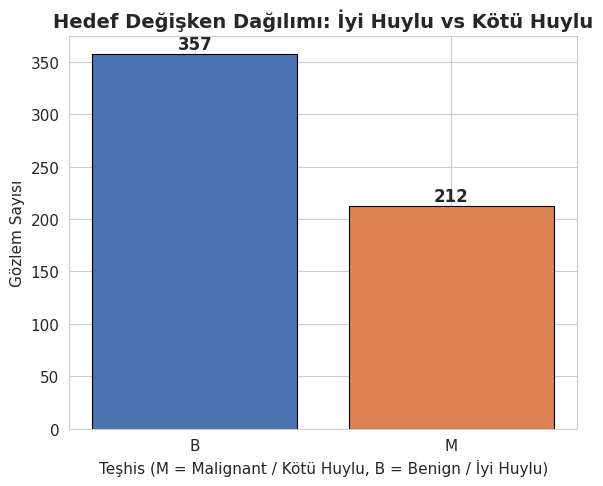

In [13]:
# Visualize the class distribution as a bar chart
# Explicitly map colors to labels to avoid mismatches caused by alphabetical sorting
color_map = {"B": "#4C72B0", "M": "#DD8452"}  # blue = Benign, orange = Malignant
bar_colors = [color_map[label] for label in class_counts.index]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(class_counts.index, class_counts.values, color=bar_colors, edgecolor="black", linewidth=0.8)

# Add count labels on top of each bar
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(count), ha="center", fontsize=12, fontweight="bold")

ax.set_title("Hedef Değişken Dağılımı: İyi Huylu vs Kötü Huylu", fontsize=14, fontweight="bold")
ax.set_xlabel("Teşhis (M = Malignant / Kötü Huylu, B = Benign / İyi Huylu)")
ax.set_ylabel("Gözlem Sayısı")
plt.tight_layout()

# Save the figure so we can reuse it in the Medium article and GitHub README
plt.savefig("class_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

### 2.2. Korelasyon Analizi

Özellikler arasındaki ilişkileri görmek için bir korelasyon matrisi oluşturalım. Bu, hem veriyi anlamamıza hem de olası çoklu doğrusal bağlantı (multicollinearity) sorunlarını fark etmemize yardımcı olur. Görselleştirmeyi sadeleştirmek için sadece "mean" (ortalama) grubundaki 10 özelliğe odaklanıyoruz.

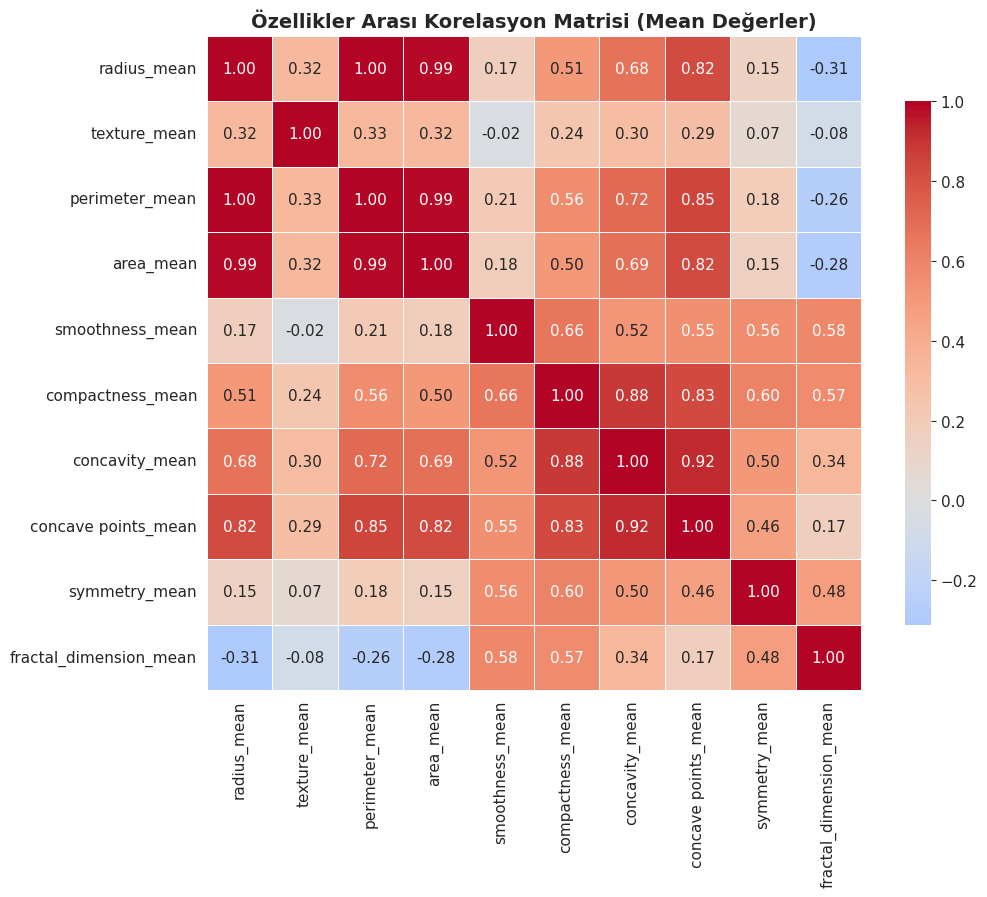

In [14]:
# Compute correlation matrix for the 'mean' features (most interpretable subset)
mean_features = [col for col in df.columns if col.endswith("_mean")]
corr_matrix = df[mean_features].corr()

# Plot the correlation heatmap
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Özellikler Arası Korelasyon Matrisi (Mean Değerler)", fontsize=14, fontweight="bold")
plt.tight_layout()

# Save the figure for later use in Medium article and GitHub README
plt.savefig("correlation_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

### 2.3. Sınıflara Göre Özellik Dağılımları

Korelasyon analizinden sonra, şimdi en ayırt edici olabilecek birkaç özelliğin iyi huylu ve kötü huylu vakalar arasında nasıl farklılaştığına bakalım. Bunun için boxplot (kutu grafiği) kullanacağız — bu grafik türü, bir dağılımın medyanını, çeyreklik değerlerini ve aykırı değerlerini (outlier) aynı anda görmemizi sağlar.

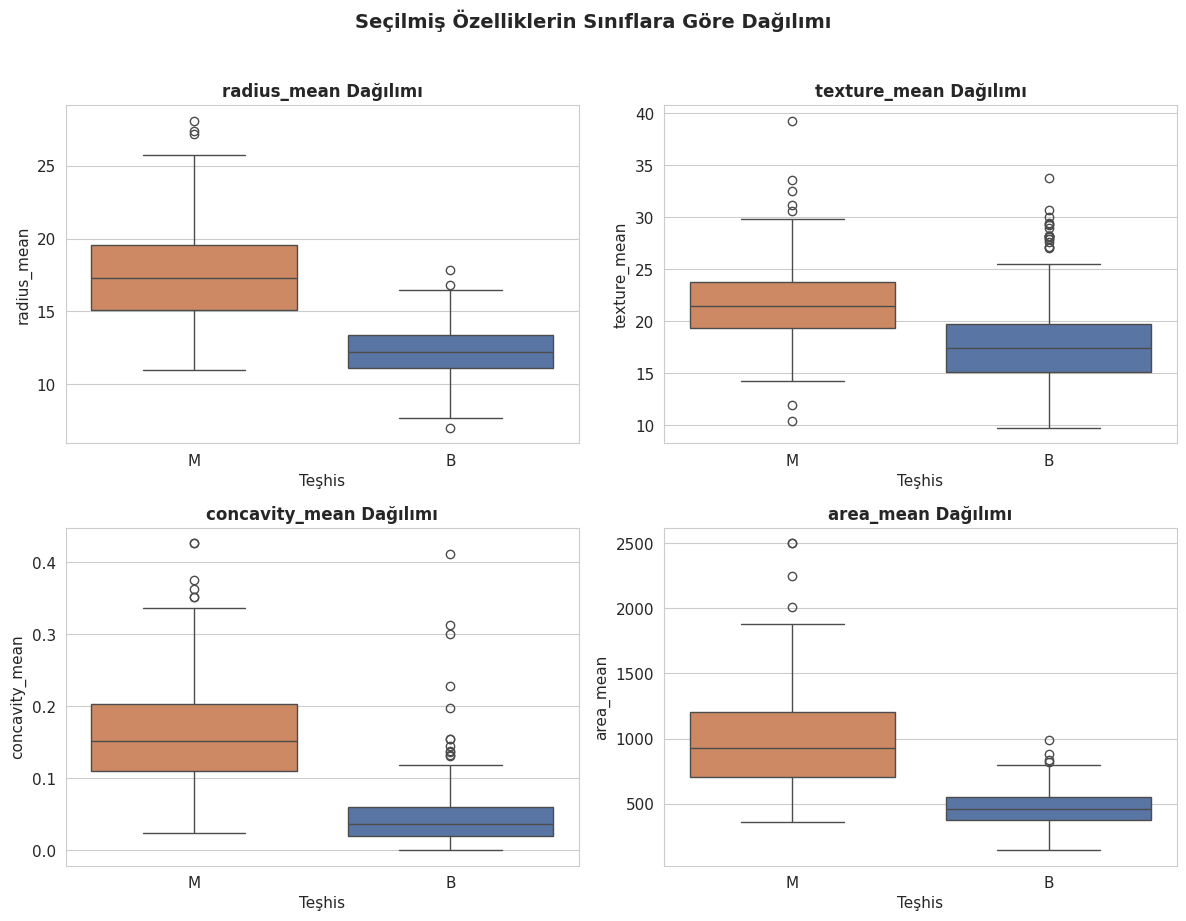

In [15]:
# Compare distributions of key features between the two classes using boxplots
key_features = ["radius_mean", "texture_mean", "concavity_mean", "area_mean"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

# Use the same color mapping as before for visual consistency (B = blue, M = orange)
palette = {"B": "#4C72B0", "M": "#DD8452"}

for i, feature in enumerate(key_features):
    sns.boxplot(data=df, x="diagnosis", y=feature, hue="diagnosis",
                palette=palette, legend=False, ax=axes[i])
    axes[i].set_title(f"{feature} Dağılımı", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Teşhis")

plt.suptitle("Seçilmiş Özelliklerin Sınıflara Göre Dağılımı", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()

# Save the figure for later use in Medium article and GitHub README
plt.savefig("feature_boxplots.png", bbox_inches="tight", dpi=150)
plt.show()

**Grafikten çıkardığımız sonuçlar:**

- **`radius_mean` ve `area_mean` çok güçlü ayırt edici özellikler:** Kötü huylu (M) ve iyi huylu (B) gruplarının kutuları neredeyse hiç örtüşmüyor. Özellikle `area_mean`'de M grubunun medyanı yaklaşık (930), B grubunun medyanının (~460) yaklaşık 2 katı — bu, tek başına bile güçlü bir tahmin sinyali olduğunu gösteriyor.
- **`concavity_mean` güçlü ama daha "gürültülü":** M grubu belirgin şekilde daha yüksek değerler alıyor, ancak B grubunda daha fazla aykırı değer (outlier) görülüyor — yani çoğu iyi huylu vaka düşük concavity gösterse de bazı istisnalar var.
- **`texture_mean` en zayıf ayırt edici:** İki grubun kutuları burada daha fazla örtüşüyor. Bu durum, korelasyon analizinde de gördüğümüz gibi `texture_mean`'in diğer özelliklerden bağımsız ve daha az belirleyici bir bilgi taşıdığını doğruluyor.

**Genel çıkarım:** "Büyüklük" temalı özellikler (`radius_mean`, `area_mean`) kötü huylu/iyi huylu ayrımında en güçlü sinyalleri taşıyor gibi görünüyor. Bu ön gözlem, ileride modelin bu özelliklere yüksek önem vermesini bekleyebileceğimize dair bir ipucu veriyor.